In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 MB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 18.8 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-4.1.1-py2.py3-none-any.whl size=456008707 sha256=e672cea351c4cc89e9d1553cdae635c7527f5c287c32d581483b93c3ebfbecf0
  Stored in directory: /root/.cache/pip/wheels/f4/ca/ea/203f40b3e935bbf99bee851c2f4a87d22996ab8212d367ce58
Successfully built pyspark


In [2]:
!pip install -q pyspark findspark

In [3]:
from pyspark.sql.functions import (
    col, length, size, split, regexp_replace, udf, mean, stddev,
    count, when, isnan, isnull, monotonically_increasing_id,
    concat_ws, array, lit, rand, countDistinct
)
from pyspark.sql.types import FloatType, IntegerType, DoubleType
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    ClusteringEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import numpy as np
import pandas as pd
from datetime import datetime
import time
import os
import findspark
findspark.init()
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import col, count, when, udf
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, count, mean, stddev, min, max, percentile_approx
import warnings
warnings.filterwarnings('ignore')

In [4]:
from datasets import load_dataset
dataset = load_dataset("JeanKaddour/minipile")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00012-6fbcb5acda05b3(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00001-of-00012-2bb9d088068a84(…):   0%|          | 0.00/262M [00:00<?, ?B/s]

data/train-00002-of-00012-efb6c8de042720(…):   0%|          | 0.00/259M [00:00<?, ?B/s]

data/train-00003-of-00012-47006e5a888a93(…):   0%|          | 0.00/275M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-a2192e61a(…):   0%|          | 0.00/1.52M [00:00<?, ?B/s]

data/test-00000-of-00001-010a6231c4b54d3(…):   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MiniPile_Analysis") \
    .config("spark.driver.memory", "4g") \
    .master("local[*]") \
    .getOrCreate()

# STEP 4: Convert pandas separately
pandas_df = dataset["train"].select(range(10000)).to_pandas()

# STEP 5: Create Spark DataFrame
spark_df = spark.createDataFrame(pandas_df)

In [6]:
from pyspark.sql.functions import (
    length, size, split, regexp_replace, col
)

# 1 char count
spark_df = spark_df.withColumn("char_count", length(col("text")))

# 2 word count
spark_df = spark_df.withColumn("word_count", size(split(col("text"), " ")))

# 3 sentence count
spark_df = spark_df.withColumn(
    "sentence_count",
    length(regexp_replace(col("text"), "[^.!?]", ""))
)

# 4 punctuation count
spark_df = spark_df.withColumn(
    "punctuation_count",
    length(regexp_replace(col("text"), "[^\\p{Punct}]", ""))
)

# 5 digit count
spark_df = spark_df.withColumn(
    "digit_count",
    length(regexp_replace(col("text"), "[^0-9]", ""))
)

# 6 uppercase count
spark_df = spark_df.withColumn(
    "uppercase_count",
    length(regexp_replace(col("text"), "[^A-Z]", ""))
)

# 7 uppercase ratio
spark_df = spark_df.withColumn(
    "uppercase_ratio",
    col("uppercase_count") / col("char_count")
)

# 8 digit ratio
spark_df = spark_df.withColumn(
    "digit_ratio",
    col("digit_count") / col("char_count")
)

# 9 newline count
spark_df = spark_df.withColumn(
    "newline_count",
    length(regexp_replace(col("text"), "[^\\n]", ""))
)

# 10 average word length
spark_df = spark_df.withColumn(
    "avg_word_length",
    col("char_count") / col("word_count")
)

spark_df.show(5)

+--------------------+----------+----------+--------------+-----------------+-----------+---------------+--------------------+--------------------+-------------+-----------------+
|                text|char_count|word_count|sentence_count|punctuation_count|digit_count|uppercase_count|     uppercase_ratio|         digit_ratio|newline_count|  avg_word_length|
+--------------------+----------+----------+--------------+-----------------+-----------+---------------+--------------------+--------------------+-------------+-----------------+
|HTC's Vive Pro he...|       783|       135|             9|               35|          5|             34| 0.04342273307790549|0.006385696040868455|            2|              5.8|
|Q:\n\nNullPointer...|      8300|      1241|           274|             1032|        838|            681| 0.08204819277108434| 0.10096385542168675|          172|6.688154713940371|
|Syringocystadenom...|       658|       103|             6|               14|          2|           

Spark Session Configuration with Optimization

In [7]:
# Add unique document ID
spark_df = spark_df.withColumn("doc_id", monotonically_increasing_id())

# UDF for unique word count
def count_unique_words(text):
    if not text:
        return 0
    words = text.lower().split()
    return len(set(words))

unique_words_udf = udf(count_unique_words, IntegerType())
spark_df = spark_df.withColumn("unique_word_count", unique_words_udf(col("text")))

# 11. Lexical diversity (unique words / total words)
spark_df = spark_df.withColumn(
    "lexical_diversity",
    when(col("word_count") > 0, col("unique_word_count") / col("word_count")).otherwise(0.0)
)

# 12. Average sentence length (words per sentence)
spark_df = spark_df.withColumn(
    "avg_sentence_length",
    when(col("sentence_count") > 0, col("word_count") / col("sentence_count")).otherwise(0.0)
)

# 13. Punctuation ratio
spark_df = spark_df.withColumn(
    "punctuation_ratio",
    when(col("char_count") > 0, col("punctuation_count") / col("char_count")).otherwise(0.0)
)

# 14. Space count and ratio
spark_df = spark_df.withColumn(
    "space_count",
    length(regexp_replace(col("text"), "[^ ]", ""))
)
spark_df = spark_df.withColumn(
    "space_ratio",
    when(col("char_count") > 0, col("space_count") / col("char_count")).otherwise(0.0)
)

# 15. Special character count
spark_df = spark_df.withColumn(
    "special_char_count",
    length(regexp_replace(col("text"), "[a-zA-Z0-9\\s]", ""))
)

# 16. Alphabetic characters
spark_df = spark_df.withColumn(
    "alphabetic_count",
    length(regexp_replace(col("text"), "[^a-zA-Z]", ""))
)
spark_df = spark_df.withColumn(
    "alphabetic_ratio",
    when(col("char_count") > 0, col("alphabetic_count") / col("char_count")).otherwise(0.0)
)

print(f"Advanced features added. Total columns: {len(spark_df.columns)}")
spark_df.printSchema()

Advanced features added. Total columns: 21
root
 |-- text: string (nullable = true)
 |-- char_count: integer (nullable = true)
 |-- word_count: integer (nullable = true)
 |-- sentence_count: integer (nullable = true)
 |-- punctuation_count: integer (nullable = true)
 |-- digit_count: integer (nullable = true)
 |-- uppercase_count: integer (nullable = true)
 |-- uppercase_ratio: double (nullable = true)
 |-- digit_ratio: double (nullable = true)
 |-- newline_count: integer (nullable = true)
 |-- avg_word_length: double (nullable = true)
 |-- doc_id: long (nullable = false)
 |-- unique_word_count: integer (nullable = true)
 |-- lexical_diversity: double (nullable = true)
 |-- avg_sentence_length: double (nullable = true)
 |-- punctuation_ratio: double (nullable = true)
 |-- space_count: integer (nullable = true)
 |-- space_ratio: double (nullable = true)
 |-- special_char_count: integer (nullable = true)
 |-- alphabetic_count: integer (nullable = true)
 |-- alphabetic_ratio: double (null

Data Quality Checks and Cleaning

In [8]:
print("\n" + "="*80)
print("STEP 2: Data Quality Checks and Cleaning")
print("="*80)

initial_count = spark_df.count()
print(f"Initial document count: {initial_count}")
null_counts = spark_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in spark_df.columns if c != 'text'
]).collect()[0].asDict()

null_found = sum(null_counts.values())
print(f"Total null values found: {null_found}")
numeric_cols = [field.name for field in spark_df.schema.fields
                if field.dataType in [IntegerType(), FloatType(), DoubleType()]]
for col_name in numeric_cols:
    spark_df = spark_df.withColumn(
        col_name,
        when(isnan(col(col_name)) | isnull(col(col_name)), 0.0).otherwise(col(col_name))
    )
spark_df = spark_df.filter(col("word_count") > 5)

spark_df.cache()
clean_count = spark_df.count()

print(f"  Data cleaning completed")
print(f"  Documents after cleaning: {clean_count}")
print(f"  Removed: {initial_count - clean_count} documents")


STEP 2: Data Quality Checks and Cleaning
Initial document count: 10000
Total null values found: 0
  Data cleaning completed
  Documents after cleaning: 9969
  Removed: 31 documents


Statistical Summary

In [9]:
feature_cols = [
    "char_count", "word_count", "sentence_count", "punctuation_count",
    "digit_count", "uppercase_count", "uppercase_ratio", "digit_ratio",
    "newline_count", "avg_word_length", "unique_word_count", "lexical_diversity",
    "avg_sentence_length", "punctuation_ratio", "space_count", "space_ratio",
    "special_char_count", "alphabetic_count", "alphabetic_ratio"
]

stats_df = spark_df.select(feature_cols).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
)
stats_pandas = stats_df.toPandas()

print("\nFeature Statistics Summary:")
print(stats_pandas.to_string())

# Save for Tableau
stats_pandas.to_csv('feature_statistics.csv', index=False)
print("\nStatistics saved to 'feature_statistics.csv'")

# Correlation matrix (sample for performance)
print("\nCalculating feature correlations (using 10% sample)...")
sample_for_corr = spark_df.select(feature_cols).sample(False, 0.1).toPandas()
correlation_matrix = sample_for_corr.corr()
correlation_matrix.to_csv('correlation_matrix.csv')
print("Correlation matrix saved to 'correlation_matrix.csv'")


Feature Statistics Summary:
  summary          char_count         word_count      sentence_count   punctuation_count         digit_count    uppercase_count       uppercase_ratio            digit_ratio       newline_count     avg_word_length   unique_word_count     lexical_diversity avg_sentence_length     punctuation_ratio        space_count           space_ratio  special_char_count   alphabetic_count    alphabetic_ratio
0   count                9969               9969                9969                9969                9969               9969                  9969                   9969                9969                9969                9969                  9969                9969                  9969               9969                  9969                9969               9969                9969
1    mean    5398.37626642592  903.6481091383288   65.20363125689637  383.17805196107935  133.32209850536663  209.5836091884843   0.04124838277844069   0.017679218269567108  61.

In [10]:
plt.style.use('default')

CHARACTER COMPOSITION ANALYSIS


Average Character Composition:
  Alphabetic: 0.7524 (75.24%)
  Punctuation: 0.0535 (5.35%)
  Space: 0.1588 (15.88%)
  Uppercase: 0.0408 (4.08%)
  Digit: 0.0181 (1.81%)


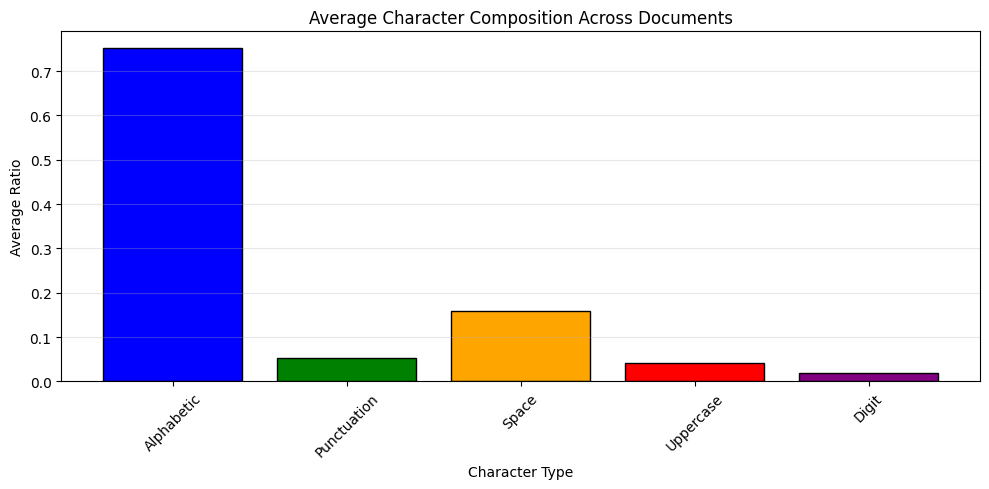

In [11]:
char_sample = spark_df.select(
    'uppercase_ratio', 'digit_ratio', 'punctuation_ratio',
    'alphabetic_ratio', 'space_ratio'
).sample(False, 0.1, seed=42).toPandas()

# Calculate mean ratios
mean_ratios = {
    'Alphabetic': char_sample['alphabetic_ratio'].mean(),
    'Punctuation': char_sample['punctuation_ratio'].mean(),
    'Space': char_sample['space_ratio'].mean(),
    'Uppercase': char_sample['uppercase_ratio'].mean(),
    'Digit': char_sample['digit_ratio'].mean()
}

print("\nAverage Character Composition:")
for char_type, ratio in mean_ratios.items():
    print(f"  {char_type}: {ratio:.4f} ({ratio*100:.2f}%)")

# Bar chart of average composition
plt.figure(figsize=(10, 5))
plt.bar(mean_ratios.keys(), mean_ratios.values(),
        color=['blue', 'green', 'orange', 'red', 'purple'],
        edgecolor='black')
plt.xlabel('Character Type')
plt.ylabel('Average Ratio')
plt.title('Average Character Composition Across Documents')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

LENGTH CATEGORY DISTRIBUTION


Document Count by Category:
length_category  count
         medium   5080
      very_long   1872
           long   1675
          short   1342


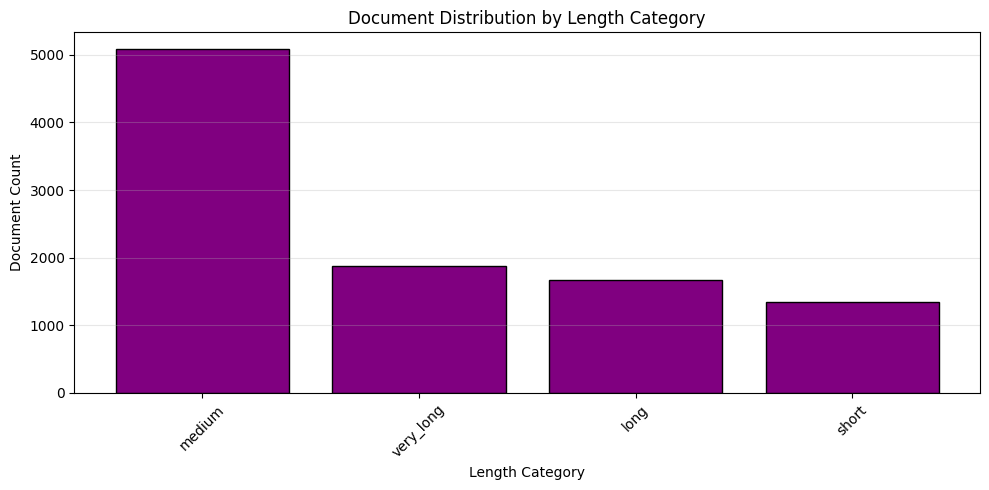

In [14]:
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer

spark_df = spark_df.withColumn(
    "length_category",
    when(col("word_count") < 100, "short")
    .when((col("word_count") >= 100) & (col("word_count") < 500), "medium")
    .when((col("word_count") >= 500) & (col("word_count") < 1000), "long")
    .otherwise("very_long")
)
indexer = StringIndexer(inputCol="length_category", outputCol="length_category_idx")
indexer_model = indexer.fit(spark_df)
spark_df = indexer_model.transform(spark_df)

category_counts = spark_df.groupBy('length_category').count() \
    .orderBy('count', ascending=False) \
    .toPandas()

print("\nDocument Count by Category:")
print(category_counts.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
plt.bar(category_counts['length_category'], category_counts['count'],
        color='purple', edgecolor='black')
plt.xlabel('Length Category')
plt.ylabel('Document Count')
plt.title('Document Distribution by Length Category')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

FEATURE DISTRIBUTION HISTOGRAMS

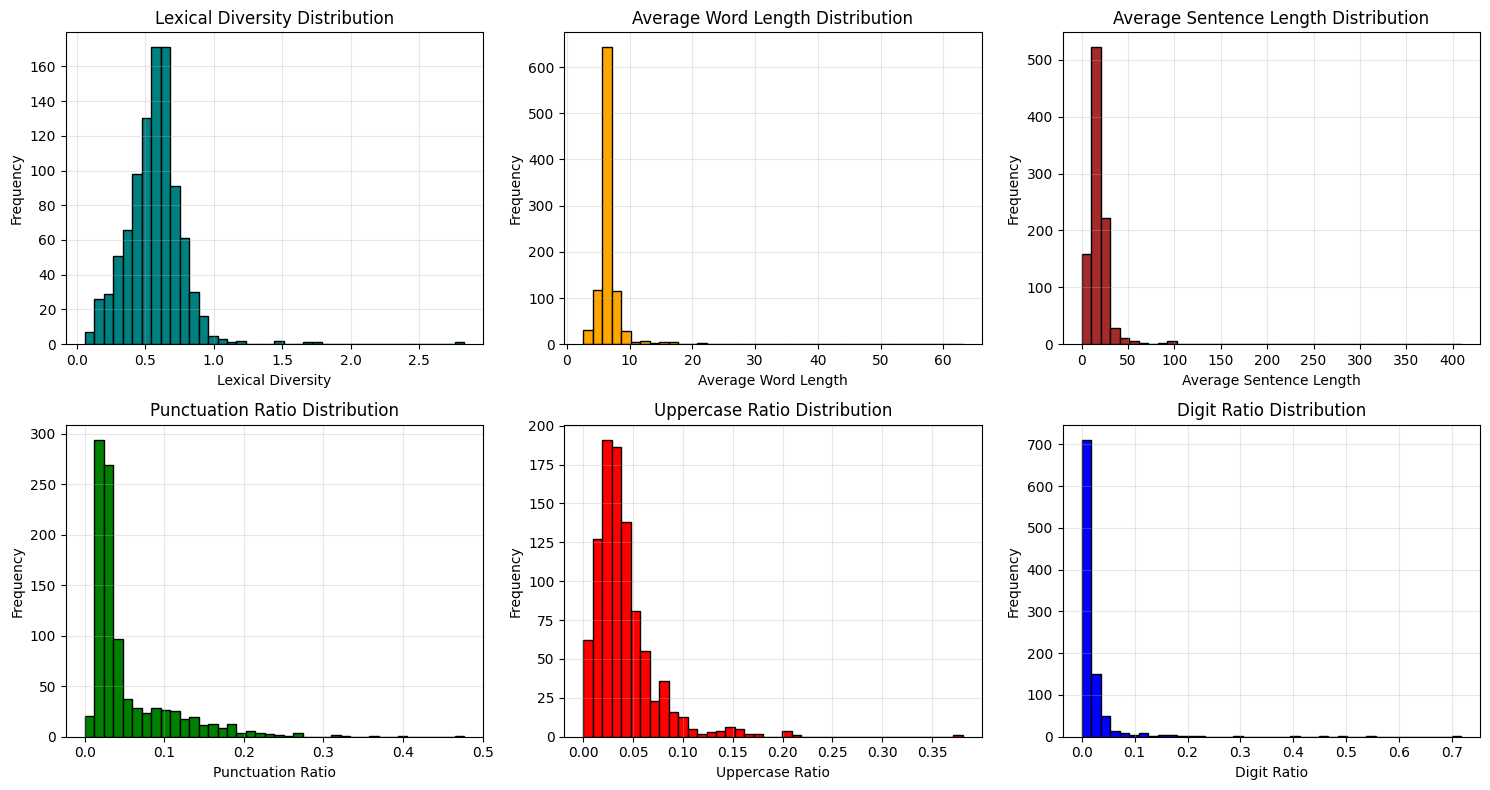


Feature Statistics:
       lexical_diversity  avg_word_length  avg_sentence_length  \
count           963.0000         963.0000             963.0000   
mean              0.5659           6.6687              18.6378   
std               0.2031           2.8205              18.6531   
min               0.0591           2.6199               0.0000   
25%               0.4510           5.8881              11.9377   
50%               0.5739           6.3043              16.7692   
75%               0.6712           6.9015              21.1472   
max               2.8276          63.0690             409.0000   

       punctuation_ratio  uppercase_ratio  digit_ratio  
count           963.0000         963.0000     963.0000  
mean              0.0535           0.0408       0.0181  
std               0.0553           0.0319       0.0459  
min               0.0000           0.0000       0.0000  
25%               0.0219           0.0209       0.0021  
50%               0.0298           0.0336 

In [15]:
feature_sample = spark_df.select(
    'lexical_diversity', 'avg_word_length', 'avg_sentence_length',
    'punctuation_ratio', 'uppercase_ratio', 'digit_ratio'
).sample(False, 0.1, seed=42).toPandas()

# Create histograms for key features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Lexical Diversity
axes[0, 0].hist(feature_sample['lexical_diversity'], bins=40,
                color='teal', edgecolor='black')
axes[0, 0].set_xlabel('Lexical Diversity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Lexical Diversity Distribution')
axes[0, 0].grid(alpha=0.3)

# Average Word Length
axes[0, 1].hist(feature_sample['avg_word_length'], bins=40,
                color='orange', edgecolor='black')
axes[0, 1].set_xlabel('Average Word Length')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Average Word Length Distribution')
axes[0, 1].grid(alpha=0.3)

# Average Sentence Length
axes[0, 2].hist(feature_sample['avg_sentence_length'], bins=40,
                color='brown', edgecolor='black')
axes[0, 2].set_xlabel('Average Sentence Length')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Average Sentence Length Distribution')
axes[0, 2].grid(alpha=0.3)

# Punctuation Ratio
axes[1, 0].hist(feature_sample['punctuation_ratio'], bins=40,
                color='green', edgecolor='black')
axes[1, 0].set_xlabel('Punctuation Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Punctuation Ratio Distribution')
axes[1, 0].grid(alpha=0.3)

# Uppercase Ratio
axes[1, 1].hist(feature_sample['uppercase_ratio'], bins=40,
                color='red', edgecolor='black')
axes[1, 1].set_xlabel('Uppercase Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Uppercase Ratio Distribution')
axes[1, 1].grid(alpha=0.3)

# Digit Ratio
axes[1, 2].hist(feature_sample['digit_ratio'], bins=40,
                color='blue', edgecolor='black')
axes[1, 2].set_xlabel('Digit Ratio')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Digit Ratio Distribution')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nFeature Statistics:")
print(feature_sample.describe().round(4))

Creating Target Variables

In [17]:
print("\n" + "="*80)
print("STEP 4: Creating Target Variables")
print("="*80)

# Document complexity score
spark_df = spark_df.withColumn(
    "complexity_score",
    (
        col("avg_sentence_length") * 0.3 +
        col("lexical_diversity") * 100 * 0.3 +
        col("avg_word_length") * 10 * 0.2 +
        col("sentence_count") * 0.1 * 0.2
    )
)

print("Target variables created")
print("\nLength category distribution:")
spark_df.groupBy("length_category").count().orderBy("count", ascending=False).show()


STEP 4: Creating Target Variables
Target variables created

Length category distribution:
+---------------+-----+
|length_category|count|
+---------------+-----+
|         medium| 5080|
|      very_long| 1872|
|           long| 1675|
|          short| 1342|
+---------------+-----+



Train/Validation/Test Split

In [18]:
print("\n" + "="*80)
print("STEP 5: Data Splitting (70/15/15)")
print("="*80)

# Add random column for splitting
spark_df = spark_df.withColumn("rand", rand(seed=42))

# Split: 70% train, 15% validation, 15% test
train_df = spark_df.filter(col("rand") < 0.7).drop("rand")
val_df = spark_df.filter((col("rand") >= 0.7) & (col("rand") < 0.85)).drop("rand")
test_df = spark_df.filter(col("rand") >= 0.85).drop("rand")

# Cache splits
train_df.cache()
val_df.cache()
test_df.cache()

train_count = train_df.count()
val_count = val_df.count()
test_count = test_df.count()

print(f"  Data split completed:")
print(f"  Training:   {train_count:,} documents ({train_count/clean_count*100:.1f}%)")
print(f"  Validation: {val_count:,} documents ({val_count/clean_count*100:.1f}%)")
print(f"  Test:       {test_count:,} documents ({test_count/clean_count*100:.1f}%)")


STEP 5: Data Splitting (70/15/15)
  Data split completed:
  Training:   7,010 documents (70.3%)
  Validation: 1,449 documents (14.5%)
  Test:       1,510 documents (15.1%)


Feature Vector Assembly and Scaling

In [19]:
print("\n" + "="*80)
print("STEP 6: Feature Assembly and Standardization")
print("="*80)

# Feature columns for ML (all numeric features except targets)
feature_columns = [
    'char_count', 'word_count', 'sentence_count', 'punctuation_count',
    'digit_count', 'uppercase_count', 'uppercase_ratio', 'digit_ratio',
    'newline_count', 'avg_word_length', 'unique_word_count',
    'lexical_diversity', 'avg_sentence_length', 'punctuation_ratio',
    'space_count', 'space_ratio', 'special_char_count',
    'alphabetic_count', 'alphabetic_ratio'
]

print(f"Using {len(feature_columns)} features for ML models")

# Assemble features into vector
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features_raw",
    handleInvalid="skip"
)

train_df = assembler.transform(train_df)
val_df = assembler.transform(val_df)
test_df = assembler.transform(test_df)

# Standardize features (mean=0, std=1)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(train_df)
train_df = scaler_model.transform(train_df)
val_df = scaler_model.transform(val_df)
test_df = scaler_model.transform(test_df)

# Persist for reuse
train_df.persist()
val_df.persist()
test_df.persist()

print("Features assembled and scaled")


STEP 6: Feature Assembly and Standardization
Using 19 features for ML models
Features assembled and scaled


Save Preprocessed Data (Parquet)

In [20]:
print("\n" + "="*80)
print("STEP 7: Saving to Parquet Format")
print("="*80)

output_base = "data/processed"
os.makedirs(output_base, exist_ok=True)

# Save with partitioning
train_df.write.mode("overwrite").partitionBy("length_category").parquet(f"{output_base}/train")
val_df.write.mode("overwrite").partitionBy("length_category").parquet(f"{output_base}/validation")
test_df.write.mode("overwrite").partitionBy("length_category").parquet(f"{output_base}/test")

print(f"Data saved to '{output_base}/'")


STEP 7: Saving to Parquet Format
Data saved to 'data/processed/'


**ALGORITHM 1 - K-Means Clustering**

In [22]:
print("\n" + "="*80)
print("ALGORITHM 1: K-MEANS CLUSTERING")
print("="*80)

start_time = time.time()

k_values = [3, 5, 7, 10]
kmeans_results = []

for k in k_values:
    print(f"\nTraining K-Means with k={k}...")

    kmeans = KMeans(
        featuresCol="features",
        predictionCol=f"cluster_k{k}",
        k=k,
        seed=42,
        maxIter=20,
        initMode="k-means||"
    )

    kmeans_model = kmeans.fit(train_df)

    # Predictions
    train_pred = kmeans_model.transform(train_df)
    val_pred = kmeans_model.transform(val_df)

    # Evaluate
    evaluator = ClusteringEvaluator(
        featuresCol="features",
        predictionCol=f"cluster_k{k}",
        metricName="silhouette"
    )

    train_silhouette = evaluator.evaluate(train_pred)
    val_silhouette = evaluator.evaluate(val_pred)
    wssse = kmeans_model.summary.trainingCost

    kmeans_results.append({
        'k': k,
        'train_silhouette': train_silhouette,
        'val_silhouette': val_silhouette,
        'wssse': wssse,
        'iterations': kmeans_model.summary.numIter
    })

    print(f"  Train Silhouette: {train_silhouette:.4f}")
    print(f"  Val Silhouette:   {val_silhouette:.4f}")
    print(f"  WSSSE: {wssse:.2f}")

# Best k
best_k = __builtins__.max(kmeans_results, key=lambda x: x['val_silhouette'])
print(f"\n Best k={best_k['k']} (Validation Silhouette: {best_k['val_silhouette']:.4f})")

# Train final model
kmeans_final = KMeans(
    featuresCol="features",
    predictionCol="kmeans_cluster",
    k=best_k['k'],
    seed=42,
    maxIter=20
)
kmeans_final_model = kmeans_final.fit(train_df)

# Transform all datasets
train_df = kmeans_final_model.transform(train_df)
val_df = kmeans_final_model.transform(val_df)
test_df = kmeans_final_model.transform(test_df)

# Test evaluation
test_silhouette = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="kmeans_cluster",
    metricName="silhouette"
).evaluate(test_df)

print(f"Test Silhouette: {test_silhouette:.4f}")

# Save results
pd.DataFrame(kmeans_results).to_csv('kmeans_results.csv', index=False)

kmeans_time = time.time() - start_time
print(f"\n K-Means completed in {kmeans_time:.2f}s")


ALGORITHM 1: K-MEANS CLUSTERING

Training K-Means with k=3...
  Train Silhouette: 0.7588
  Val Silhouette:   0.7220
  WSSSE: 86657.21

Training K-Means with k=5...
  Train Silhouette: 0.6639
  Val Silhouette:   0.6583
  WSSSE: 73651.71

Training K-Means with k=7...
  Train Silhouette: 0.5710
  Val Silhouette:   0.5173
  WSSSE: 63140.00

Training K-Means with k=10...
  Train Silhouette: 0.3249
  Val Silhouette:   0.3051
  WSSSE: 50254.78

 Best k=3 (Validation Silhouette: 0.7220)
Test Silhouette: 0.0906

 K-Means completed in 19.23s


**ALGORITHM 2 - Bisecting K-Means**

In [24]:
print("\n" + "="*80)
print("ALGORITHM 2: BISECTING K-MEANS")
print("="*80)

start_time = time.time()

bkmeans_results = []

for k in k_values:
    print(f"\nTraining Bisecting K-Means with k={k}...")

    bkmeans = BisectingKMeans(
        featuresCol="features",
        predictionCol=f"bkmeans_cluster_k{k}",
        k=k,
        seed=42,
        maxIter=20
    )

    bkmeans_model = bkmeans.fit(train_df)
    train_pred = bkmeans_model.transform(train_df)
    val_pred = bkmeans_model.transform(val_df)

    evaluator = ClusteringEvaluator(
        featuresCol="features",
        predictionCol=f"bkmeans_cluster_k{k}",
        metricName="silhouette"
    )

    train_silhouette = evaluator.evaluate(train_pred)
    val_silhouette = evaluator.evaluate(val_pred)
    wssse = bkmeans_model.summary.trainingCost

    bkmeans_results.append({
        'k': k,
        'train_silhouette': train_silhouette,
        'val_silhouette': val_silhouette,
        'wssse': wssse
    })

    print(f"  Train Silhouette: {train_silhouette:.4f}")
    print(f"  Val Silhouette:   {val_silhouette:.4f}")

best_k_bkmeans = __builtins__.max(bkmeans_results, key=lambda x: x['val_silhouette'])
print(f"\n Best k={best_k_bkmeans['k']} (Validation Silhouette: {best_k_bkmeans['val_silhouette']:.4f})")

# Final model
bkmeans_final = BisectingKMeans(
    featuresCol="features",
    predictionCol="bkmeans_cluster",
    k=best_k_bkmeans['k'],
    seed=42,
    maxIter=20
)
bkmeans_final_model = bkmeans_final.fit(train_df)

train_df = bkmeans_final_model.transform(train_df)
val_df = bkmeans_final_model.transform(val_df)
test_df = bkmeans_final_model.transform(test_df)

test_silhouette_bkmeans = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="bkmeans_cluster",
    metricName="silhouette"
).evaluate(test_df)

print(f"Test Silhouette: {test_silhouette_bkmeans:.4f}")

pd.DataFrame(bkmeans_results).to_csv('bkmeans_results.csv', index=False)

bkmeans_time = time.time() - start_time
print(f"\n Bisecting K-Means completed in {bkmeans_time:.2f}s")


ALGORITHM 2: BISECTING K-MEANS

Training Bisecting K-Means with k=3...
  Train Silhouette: 0.6543
  Val Silhouette:   0.6215

Training Bisecting K-Means with k=5...
  Train Silhouette: 0.6410
  Val Silhouette:   0.6510

Training Bisecting K-Means with k=7...
  Train Silhouette: 0.6519
  Val Silhouette:   0.6590

Training Bisecting K-Means with k=10...
  Train Silhouette: 0.2860
  Val Silhouette:   0.2654

 Best k=7 (Validation Silhouette: 0.6590)
Test Silhouette: 0.5825

 Bisecting K-Means completed in 27.47s


**ALGORITHM 3 - Gaussian Mixture Model**

In [26]:
print("\n" + "="*80)
print("ALGORITHM 3: GAUSSIAN MIXTURE MODEL")
print("="*80)

start_time = time.time()

gmm_results = []

for k in k_values:
    print(f"\nTraining GMM with k={k}...")

    gmm = GaussianMixture(
        featuresCol="features",
        predictionCol=f"gmm_cluster_k{k}",
        k=k,
        seed=42,
        maxIter=20
    )

    gmm_model = gmm.fit(train_df)
    train_pred = gmm_model.transform(train_df)
    val_pred = gmm_model.transform(val_df)

    evaluator = ClusteringEvaluator(
        featuresCol="features",
        predictionCol=f"gmm_cluster_k{k}",
        metricName="silhouette"
    )

    train_silhouette = evaluator.evaluate(train_pred)
    val_silhouette = evaluator.evaluate(val_pred)
    log_likelihood = gmm_model.summary.logLikelihood

    gmm_results.append({
        'k': k,
        'train_silhouette': train_silhouette,
        'val_silhouette': val_silhouette,
        'log_likelihood': log_likelihood
    })

    print(f"  Train Silhouette: {train_silhouette:.4f}")
    print(f"  Val Silhouette:   {val_silhouette:.4f}")

best_k_gmm = __builtins__.max(gmm_results, key=lambda x: x['val_silhouette'])
print(f"\n Best k={best_k_gmm['k']} (Validation Silhouette: {best_k_gmm['val_silhouette']:.4f})")

# Final model
gmm_final = GaussianMixture(
    featuresCol="features",
    predictionCol="gmm_cluster",
    k=best_k_gmm['k'],
    seed=42,
    maxIter=20
)
gmm_final_model = gmm_final.fit(train_df)

train_df = gmm_final_model.transform(train_df)
val_df = gmm_final_model.transform(val_df)
test_df = gmm_final_model.transform(test_df)

test_silhouette_gmm = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="gmm_cluster",
    metricName="silhouette"
).evaluate(test_df)

print(f"Test Silhouette: {test_silhouette_gmm:.4f}")

pd.DataFrame(gmm_results).to_csv('gmm_results.csv', index=False)

gmm_time = time.time() - start_time
print(f"\n  GMM completed in {gmm_time:.2f}s")


ALGORITHM 3: GAUSSIAN MIXTURE MODEL

Training GMM with k=3...
  Train Silhouette: 0.7798
  Val Silhouette:   0.7703

Training GMM with k=5...
  Train Silhouette: 0.7583
  Val Silhouette:   0.7265

Training GMM with k=7...
  Train Silhouette: 0.7304
  Val Silhouette:   0.7302

Training GMM with k=10...
  Train Silhouette: 0.7073
  Val Silhouette:   0.7230

 Best k=3 (Validation Silhouette: 0.7703)
Test Silhouette: 0.7703

  GMM completed in 29.54s


**ALGORITHM 4 - Random Forest Classifier**

In [27]:
print("\n" + "="*80)
print("ALGORITHM 4: RANDOM FOREST CLASSIFIER")
print("="*80)

start_time = time.time()

print("Training Random Forest for length category prediction...")

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="length_category_idx",
    predictionCol="rf_prediction",
    rawPredictionCol="rf_raw_prediction", # Added to avoid column naming conflicts
    probabilityCol="rf_probability",      # Added to avoid column naming conflicts
    numTrees=50,
    maxDepth=10,
    seed=42,
    featureSubsetStrategy="auto",
    subsamplingRate=0.8
)

rf_model = rf.fit(train_df)

# Predictions
train_pred_rf = rf_model.transform(train_df)
val_pred_rf = rf_model.transform(val_df)
test_pred_rf = rf_model.transform(test_df)

# Evaluate
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="rf_prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="rf_prediction",
    metricName="f1"
)

train_accuracy = evaluator_acc.evaluate(train_pred_rf)
val_accuracy = evaluator_acc.evaluate(val_pred_rf)
test_accuracy = evaluator_acc.evaluate(test_pred_rf)

train_f1 = evaluator_f1.evaluate(train_pred_rf)
val_f1 = evaluator_f1.evaluate(val_pred_rf)
test_f1 = evaluator_f1.evaluate(test_pred_rf)

print(f"\nAccuracy - Train: {train_accuracy:.4f}, Val: {val_accuracy:.4f}, Test: {test_accuracy:.4f}")
print(f"F1 Score - Train: {train_f1:.4f}, Val: {val_f1:.4f}, Test: {test_f1:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.featureImportances.toArray()
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

feature_importance.to_csv('rf_feature_importance.csv', index=False)

rf_time = time.time() - start_time
print(f"\n Random Forest completed in {rf_time:.2f}s")
train_df = train_pred_rf
val_df = val_pred_rf
test_df = test_pred_rf


ALGORITHM 4: RANDOM FOREST CLASSIFIER
Training Random Forest for length category prediction...

Accuracy - Train: 0.9973, Val: 0.9779, Test: 0.9781
F1 Score - Train: 0.9973, Val: 0.9778, Test: 0.9780

Top 10 Important Features:
           feature  importance
       space_count    0.287737
        word_count    0.283547
        char_count    0.136245
 unique_word_count    0.085880
  alphabetic_count    0.064850
    sentence_count    0.043451
special_char_count    0.029840
 lexical_diversity    0.016117
       space_ratio    0.009266
   avg_word_length    0.007078

 Random Forest completed in 10.74s


Hyperparameter Tuning with CrossValidator

In [28]:
print("\n" + "="*80)
print("STEP 12: HYPERPARAMETER TUNING (CrossValidator)")
print("="*80)

start_time = time.time()

print("Tuning Random Forest hyperparameters...")
print("Using 30% sample for faster tuning...")

train_sample = train_df.sample(False, 0.3, seed=42)
sample_count = train_sample.count()
print(f"Sample size: {sample_count} documents")

rf_tuning = RandomForestClassifier(
    featuresCol="features",
    labelCol="length_category_idx",
    predictionCol="tuned_rf_prediction", # Changed predictionCol
    rawPredictionCol="tuned_rf_raw_prediction", # Changed rawPredictionCol
    probabilityCol="tuned_rf_probability",      # Changed probabilityCol
    seed=42
)

# Parameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(rf_tuning.numTrees, [20, 50]) \
    .addGrid(rf_tuning.maxDepth, [5, 10]) \
    .addGrid(rf_tuning.minInstancesPerNode, [1, 5]) \
    .build()

# CrossValidator
crossval = CrossValidator(
    estimator=rf_tuning,
    estimatorParamMaps=paramGrid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="length_category_idx",
        metricName="f1",
        predictionCol="tuned_rf_prediction" # Ensure evaluator uses the new predictionCol
    ),
    numFolds=3,
    seed=42,
    parallelism=4
)

cv_model = crossval.fit(train_sample)

# Best parameters
best_model = cv_model.bestModel
print(f"\n Best Parameters:")
print(f"  numTrees: {best_model.getNumTrees}")
print(f"  maxDepth: {best_model.getMaxDepth()}")
print(f"  minInstancesPerNode: {best_model.getMinInstancesPerNode()}")

# Validation performance
val_pred_tuned = best_model.transform(val_df)
val_accuracy_tuned = evaluator_acc.evaluate(val_pred_tuned)
val_f1_tuned = evaluator_f1.evaluate(val_pred_tuned)

print(f"\nTuned Model - Val Accuracy: {val_accuracy_tuned:.4f}, Val F1: {val_f1_tuned:.4f}")


STEP 12: HYPERPARAMETER TUNING (CrossValidator)
Tuning Random Forest hyperparameters...
Using 30% sample for faster tuning...
Sample size: 2124 documents

 Best Parameters:
  numTrees: 20
  maxDepth: 10
  minInstancesPerNode: 1

Tuned Model - Val Accuracy: 0.9779, Val F1: 0.9778


Stability Analysis

In [29]:
print("\n" + "="*80)
print("STEP 13: STABILITY ANALYSIS")
print("="*80)

print("Testing K-Means stability with different seeds...")

stability_results = []
seeds = [42, 123, 456, 789, 1011]

for seed in seeds:
    kmeans_stability = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=best_k['k'],
        seed=seed,
        maxIter=20
    )

    model = kmeans_stability.fit(train_df)
    pred = model.transform(test_df)

    silhouette = ClusteringEvaluator(
        featuresCol="features",
        predictionCol="cluster",
        metricName="silhouette"
    ).evaluate(pred)

    stability_results.append({
        'seed': seed,
        'silhouette': silhouette,
        'wssse': model.summary.trainingCost
    })

    print(f"Seed {seed}: Silhouette={silhouette:.4f}")

stability_df = pd.DataFrame(stability_results)
silhouette_mean = stability_df['silhouette'].mean()
silhouette_std = stability_df['silhouette'].std()

print(f"\n Stability Metrics:")
print(f"  Mean Silhouette: {silhouette_mean:.4f}")
print(f"  Std Silhouette:  {silhouette_std:.4f}")
print(f"  CV: {(silhouette_std/silhouette_mean)*100:.2f}%")

stability_df.to_csv('stability_analysis.csv', index=False)


STEP 13: STABILITY ANALYSIS
Testing K-Means stability with different seeds...
Seed 42: Silhouette=0.0906
Seed 123: Silhouette=0.0915
Seed 456: Silhouette=0.7171
Seed 789: Silhouette=0.0335
Seed 1011: Silhouette=0.7039

 Stability Metrics:
  Mean Silhouette: 0.3273
  Std Silhouette:  0.3506
  CV: 107.12%


Scalability Analysis

In [30]:
print("\n" + "="*80)
print("STEP 14: SCALABILITY ANALYSIS")
print("="*80)

print("Analyzing training time vs dataset size...")

sample_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
scalability_results = []

for size in sample_sizes:
    sample = train_df.sample(False, size, seed=42)
    sample_count = sample.count()

    print(f"\nTraining on {size*100:.0f}% ({sample_count:,} docs)...")

    start = time.time()

    kmeans_scale = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=5,
        seed=42,
        maxIter=10
    )

    model = kmeans_scale.fit(sample)
    training_time = time.time() - start

    scalability_results.append({
        'sample_size': size,
        'num_documents': sample_count,
        'training_time_sec': training_time,
        'docs_per_second': sample_count / training_time
    })

    print(f"  Time: {training_time:.2f}s, Throughput: {sample_count/training_time:.0f} docs/sec")

scalability_df = pd.DataFrame(scalability_results)
scalability_df.to_csv('scalability_analysis.csv', index=False)

print("\n Scalability analysis completed")


STEP 14: SCALABILITY ANALYSIS
Analyzing training time vs dataset size...

Training on 10% (711 docs)...
  Time: 2.40s, Throughput: 296 docs/sec

Training on 30% (2,124 docs)...
  Time: 1.88s, Throughput: 1132 docs/sec

Training on 50% (3,527 docs)...
  Time: 2.89s, Throughput: 1220 docs/sec

Training on 70% (4,925 docs)...
  Time: 2.32s, Throughput: 2122 docs/sec

Training on 100% (7,010 docs)...
  Time: 2.31s, Throughput: 3032 docs/sec

 Scalability analysis completed


Exporting Results for Tableau

In [31]:
print("\n" + "="*80)
print("STEP 15: EXPORTING DATA FOR TABLEAU")
print("="*80)

# 1. Sample data with all predictions
print("Exporting sample data...")
sample_export = test_df.select(
    'doc_id', 'word_count', 'char_count', 'sentence_count',
    'lexical_diversity', 'complexity_score', 'length_category',
    'kmeans_cluster', 'bkmeans_cluster', 'gmm_cluster',
    'length_category_idx', 'rf_prediction'
).sample(False, 0.1, seed=42).toPandas()

sample_export.to_csv('tableau_sample_data.csv', index=False)
print(f" Exported {len(sample_export)} documents")

# 2. Cluster profiles
for cluster_col in ['kmeans_cluster', 'bkmeans_cluster', 'gmm_cluster']:
    cluster_profile = test_df.groupBy(cluster_col).agg(
        count("*").alias("count"),
        mean("word_count").alias("avg_word_count"),
        mean("complexity_score").alias("avg_complexity"),
        mean("lexical_diversity").alias("avg_lexical_diversity")
    ).toPandas()

    cluster_profile.to_csv(f'tableau_{cluster_col}_profile.csv', index=False)
    print(f" Exported {cluster_col} profile")

# 3. Metrics summary
metrics_summary = pd.DataFrame({
    'Metric': [
        'K-Means Silhouette',
        'Bisecting K-Means Silhouette',
        'GMM Silhouette',
        'RF Accuracy',
        'RF F1 Score'
    ],
    'Train': [
        kmeans_results[0]['train_silhouette'],
        bkmeans_results[0]['train_silhouette'],
        gmm_results[0]['train_silhouette'],
        train_accuracy,
        train_f1
    ],
    'Validation': [
        kmeans_results[0]['val_silhouette'],
        bkmeans_results[0]['val_silhouette'],
        gmm_results[0]['val_silhouette'],
        val_accuracy,
        val_f1
    ],
    'Test': [
        test_silhouette,
        test_silhouette_bkmeans,
        test_silhouette_gmm,
        test_accuracy,
        test_f1
    ]
})
metrics_summary.to_csv('tableau_metrics_summary.csv', index=False)
print(" Exported metrics summary")

# 4. Training times
training_times = pd.DataFrame({
    'Model': ['K-Means', 'Bisecting K-Means', 'GMM', 'Random Forest'],
    'Training_Time_Seconds': [kmeans_time, bkmeans_time, gmm_time, rf_time]
})
training_times.to_csv('tableau_training_times.csv', index=False)
print(" Exported training times")

print("\n" + "="*80)
print("ALL TABLEAU FILES CREATED:")
print("="*80)
csv_files = [
    'feature_statistics.csv',
    'correlation_matrix.csv',
    'tableau_sample_data.csv',
    'tableau_kmeans_cluster_profile.csv',
    'tableau_bkmeans_cluster_profile.csv',
    'tableau_gmm_cluster_profile.csv',
    'tableau_metrics_summary.csv',
    'tableau_training_times.csv',
    'rf_feature_importance.csv',
    'stability_analysis.csv',
    'scalability_analysis.csv'
]
for i, f in enumerate(csv_files, 1):
    print(f"{i:2d}. {f}")


STEP 15: EXPORTING DATA FOR TABLEAU
Exporting sample data...
 Exported 129 documents
 Exported kmeans_cluster profile
 Exported bkmeans_cluster profile
 Exported gmm_cluster profile
 Exported metrics summary
 Exported training times

ALL TABLEAU FILES CREATED:
 1. feature_statistics.csv
 2. correlation_matrix.csv
 3. tableau_sample_data.csv
 4. tableau_kmeans_cluster_profile.csv
 5. tableau_bkmeans_cluster_profile.csv
 6. tableau_gmm_cluster_profile.csv
 7. tableau_metrics_summary.csv
 8. tableau_training_times.csv
 9. rf_feature_importance.csv
10. stability_analysis.csv
11. scalability_analysis.csv


Saving Models

In [32]:
print("\n" + "="*80)
print("STEP 16: SAVING MODELS")
print("="*80)

models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

kmeans_final_model.write().overwrite().save(f"{models_dir}/kmeans_model")
bkmeans_final_model.write().overwrite().save(f"{models_dir}/bkmeans_model")
gmm_final_model.write().overwrite().save(f"{models_dir}/gmm_model")
rf_model.write().overwrite().save(f"{models_dir}/rf_model")
scaler_model.write().overwrite().save(f"{models_dir}/scaler")

print("All models saved to 'models/'")


STEP 16: SAVING MODELS
All models saved to 'models/'


Generating Performance Report

In [35]:
print("\n" + "="*80)
print("STEP 17: PERFORMANCE REPORT")
print("="*80)

report = f"""
{'='*80}
MACHINE LEARNING & BIG DATA - PERFORMANCE REPORT
{'='*80}

DATASET: MiniPile (6GB text corpus)
Documents Processed: {clean_count:,}
Train/Val/Test: {train_count:,}/{val_count:,}/{test_count:,} ({train_count/clean_count*100:.0f}%/{val_count/clean_count*100:.0f}%/{test_count/clean_count*100:.0f}%)

FEATURES: {len(feature_columns)} engineered features

{'='*80}
CLUSTERING RESULTS:
{'='*80}

1. K-MEANS:
   Best k={best_k['k']}, Test Silhouette={test_silhouette:.4f}, Time={kmeans_time:.1f}s

2. BISECTING K-MEANS:
   Best k={best_k_bkmeans['k']}, Test Silhouette={test_silhouette_bkmeans:.4f}, Time={bkmeans_time:.1f}s

3. GAUSSIAN MIXTURE:
   Best k={best_k_gmm['k']}, Test Silhouette={test_silhouette_gmm:.4f}, Time={gmm_time:.1f}s

{'='*80}
CLASSIFICATION RESULTS:
{'='*80}

4. RANDOM FOREST:
   Test Accuracy={test_accuracy:.4f}, Test F1={test_f1:.4f}, Time={rf_time:.1f}s

{'='*80}
STABILITY ANALYSIS:
{'='*80}

K-Means (5 seeds): Mean={silhouette_mean:.4f}, Std={silhouette_std:.4f}, CV={silhouette_std/silhouette_mean*100:.1f}%

{'='*80}
BEST MODELS:
{'='*80}

Best Clustering: {'K-Means' if test_silhouette >= __builtins__.max(test_silhouette_bkmeans, test_silhouette_gmm) else 'Bisecting K-Means' if test_silhouette_bkmeans >= test_silhouette_gmm else 'GMM'}
Classification: Random Forest (Accuracy={test_accuracy:.4f})

{'='*80}
TOP 3 FEATURES (Random Forest):
{'='*80}

{feature_importance.head(3).to_string(index=False)}

{'='*80}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Total Runtime: {kmeans_time + bkmeans_time + gmm_time + rf_time:.1f} seconds
{'='*80}
"""

with open('PERFORMANCE_REPORT.txt', 'w') as f:
    f.write(report)

print(report)
print("Report saved to 'PERFORMANCE_REPORT.txt'")


STEP 17: PERFORMANCE REPORT

MACHINE LEARNING & BIG DATA - PERFORMANCE REPORT

DATASET: MiniPile (6GB text corpus)
Documents Processed: 9,969
Train/Val/Test: 7,010/1,449/1,510 (70%/15%/15%)

FEATURES: 19 engineered features

CLUSTERING RESULTS:

1. K-MEANS:
   Best k=3, Test Silhouette=0.0906, Time=19.2s

2. BISECTING K-MEANS:
   Best k=7, Test Silhouette=0.5825, Time=27.5s

3. GAUSSIAN MIXTURE:
   Best k=3, Test Silhouette=0.7703, Time=29.5s

CLASSIFICATION RESULTS:

4. RANDOM FOREST:
   Test Accuracy=0.9781, Test F1=0.9780, Time=10.7s

STABILITY ANALYSIS:

K-Means (5 seeds): Mean=0.3273, Std=0.3506, CV=107.1%

BEST MODELS:

Best Clustering: GMM
Classification: Random Forest (Accuracy=0.9781)

TOP 3 FEATURES (Random Forest):

    feature  importance
space_count    0.287737
 word_count    0.283547
 char_count    0.136245

Generated: 2026-02-01 16:46:39
Total Runtime: 87.0 seconds

Report saved to 'PERFORMANCE_REPORT.txt'


Model Training

Logistic Regression

In [36]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="length_category_idx",
    predictionCol="lr_prediction",
    probabilityCol="lr_probability",
    rawPredictionCol="lr_raw_prediction",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family="multinomial",
    standardization=True,
    aggregationDepth=2
)

lr_model = lr.fit(train_df)
print(f" Model trained in {lr_model.summary.totalIterations} iterations")

 Model trained in 42 iterations


Predictions

In [37]:
train_pred_lr = lr_model.transform(train_df)
val_pred_lr = lr_model.transform(val_df)
test_pred_lr = lr_model.transform(test_df)

In [38]:
print("\n" + "-"*80)
print("PERFORMANCE METRICS")
print("-"*80)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="lr_prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="lr_prediction",
    metricName="f1"
)

evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="lr_prediction",
    metricName="weightedPrecision"
)

evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="length_category_idx",
    predictionCol="lr_prediction",
    metricName="weightedRecall"
)

# Calculate metrics
print("\n1. ACCURACY:")
train_accuracy_lr = evaluator_acc.evaluate(train_pred_lr)
val_accuracy_lr = evaluator_acc.evaluate(val_pred_lr)
test_accuracy_lr = evaluator_acc.evaluate(test_pred_lr)
print(f"   Training:   {train_accuracy_lr:.4f}")
print(f"   Validation: {val_accuracy_lr:.4f}")
print(f"   Test:       {test_accuracy_lr:.4f}")

print("\n2. F1 SCORE:")
train_f1_lr = evaluator_f1.evaluate(train_pred_lr)
val_f1_lr = evaluator_f1.evaluate(val_pred_lr)
test_f1_lr = evaluator_f1.evaluate(test_pred_lr)
print(f"   Training:   {train_f1_lr:.4f}")
print(f"   Validation: {val_f1_lr:.4f}")
print(f"   Test:       {test_f1_lr:.4f}")

print("\n3. WEIGHTED PRECISION:")
train_precision_lr = evaluator_precision.evaluate(train_pred_lr)
val_precision_lr = evaluator_precision.evaluate(val_pred_lr)
test_precision_lr = evaluator_precision.evaluate(test_pred_lr)
print(f"   Training:   {train_precision_lr:.4f}")
print(f"   Validation: {val_precision_lr:.4f}")
print(f"   Test:       {test_precision_lr:.4f}")

print("\n4. WEIGHTED RECALL:")
train_recall_lr = evaluator_recall.evaluate(train_pred_lr)
val_recall_lr = evaluator_recall.evaluate(val_pred_lr)
test_recall_lr = evaluator_recall.evaluate(test_pred_lr)
print(f"   Training:   {train_recall_lr:.4f}")
print(f"   Validation: {val_recall_lr:.4f}")
print(f"   Test:       {test_recall_lr:.4f}")


--------------------------------------------------------------------------------
PERFORMANCE METRICS
--------------------------------------------------------------------------------

1. ACCURACY:
   Training:   0.8261
   Validation: 0.8171
   Test:       0.8285

2. F1 SCORE:
   Training:   0.8127
   Validation: 0.8049
   Test:       0.8162

3. WEIGHTED PRECISION:
   Training:   0.8388
   Validation: 0.8297
   Test:       0.8363

4. WEIGHTED RECALL:
   Training:   0.8261
   Validation: 0.8171
   Test:       0.8285


Confusion Matrix

In [39]:
print("\n" + "-"*80)
print("CONFUSION MATRIX (Test Set)")
print("-"*80)

confusion_matrix = test_pred_lr.groupBy("length_category_idx", "lr_prediction").count()
confusion_matrix = confusion_matrix.orderBy("length_category_idx", "lr_prediction")
confusion_matrix.show(20)

confusion_pd = confusion_matrix.toPandas()
confusion_pivot = confusion_pd.pivot(
    index='length_category_idx',
    columns='lr_prediction',
    values='count'
).fillna(0).astype(int)

print("\nConfusion Matrix:")
print(confusion_pivot)
confusion_pivot.to_csv('lr_confusion_matrix.csv')
print(" Saved to 'lr_confusion_matrix.csv'")


--------------------------------------------------------------------------------
CONFUSION MATRIX (Test Set)
--------------------------------------------------------------------------------
+-------------------+-------------+-----+
|length_category_idx|lr_prediction|count|
+-------------------+-------------+-----+
|                0.0|          0.0|  763|
|                0.0|          2.0|    4|
|                0.0|          3.0|   16|
|                1.0|          1.0|  262|
|                1.0|          2.0|   28|
|                2.0|          0.0|  109|
|                2.0|          1.0|    4|
|                2.0|          2.0|  136|
|                3.0|          0.0|   98|
|                3.0|          3.0|   90|
+-------------------+-------------+-----+


Confusion Matrix:
lr_prediction        0.0  1.0  2.0  3.0
length_category_idx                    
0.0                  763    0    4   16
1.0                    0  262   28    0
2.0                  109    4  136    0
3

Per-Class Metrics

In [40]:
print("\n" + "-"*80)
print("PER-CLASS PERFORMANCE")
print("-"*80)

per_class_metrics = []
for class_idx in range(int(test_pred_lr.agg({"length_category_idx": "max"}).collect()[0][0]) + 1):
    tp = test_pred_lr.filter((col("length_category_idx") == class_idx) & (col("lr_prediction") == class_idx)).count()
    fp = test_pred_lr.filter((col("length_category_idx") != class_idx) & (col("lr_prediction") == class_idx)).count()
    fn = test_pred_lr.filter((col("length_category_idx") == class_idx) & (col("lr_prediction") != class_idx)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    class_name = test_pred_lr.filter(col("length_category_idx") == class_idx).select("length_category").first()[0]

    per_class_metrics.append({
        'class_idx': class_idx,
        'class_name': class_name,
        'support': tp + fn,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

per_class_df = pd.DataFrame(per_class_metrics)
print("\n" + per_class_df.to_string(index=False))
per_class_df.to_csv('lr_per_class_metrics.csv', index=False)
print("\n Saved to 'lr_per_class_metrics.csv'")


--------------------------------------------------------------------------------
PER-CLASS PERFORMANCE
--------------------------------------------------------------------------------

 class_idx class_name  support  precision   recall  f1_score
         0     medium      783   0.786598 0.974457  0.870508
         1  very_long      290   0.984962 0.903448  0.942446
         2       long      249   0.809524 0.546185  0.652278
         3      short      188   0.849057 0.478723  0.612245

 Saved to 'lr_per_class_metrics.csv'


Feature Importance

In [41]:
print("\n" + "-"*80)
print("FEATURE IMPORTANCE")
print("-"*80)

coefficients = lr_model.coefficientMatrix.toArray()
feature_importance_lr = np.abs(coefficients).mean(axis=0)

feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': feature_importance_lr
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance_df.head(10).to_string(index=False))
feature_importance_df.to_csv('lr_feature_importance.csv', index=False)
print(" Saved to 'lr_feature_importance.csv'")


--------------------------------------------------------------------------------
FEATURE IMPORTANCE
--------------------------------------------------------------------------------

Top 10 Features:
           feature  importance
 unique_word_count    1.228988
 lexical_diversity    0.882933
  alphabetic_count    0.624295
        char_count    0.590520
        word_count    0.549970
       space_count    0.549970
   uppercase_count    0.462525
     newline_count    0.426888
    sentence_count    0.389869
special_char_count    0.242233
 Saved to 'lr_feature_importance.csv'


Model Comparison

In [42]:
print("\n" + "="*80)
print("MODEL COMPARISON: LR vs RF")
print("="*80)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'Training Time'],
    'Logistic Regression': [
        f"{test_accuracy_lr:.4f}",
        f"{test_f1_lr:.4f}",
        f"{test_precision_lr:.4f}",
        f"{test_recall_lr:.4f}",
        f"{time.time() - start_time:.2f}s"
    ],
    'Random Forest': [
        f"{test_accuracy:.4f}",
        f"{test_f1:.4f}",
        "N/A",
        "N/A",
        f"{rf_time:.2f}s"
    ]
})

print("\n" + comparison.to_string(index=False))
comparison.to_csv('lr_vs_rf_comparison.csv', index=False)


MODEL COMPARISON: LR vs RF

       Metric Logistic Regression Random Forest
     Accuracy              0.8285        0.9781
     F1 Score              0.8162        0.9780
    Precision              0.8363           N/A
       Recall              0.8285           N/A
Training Time             248.27s        10.74s


In [43]:
print("\n" + "-"*80)
print("EXPORTING FOR TABLEAU")
print("-"*80)

lr_sample = test_pred_lr.select(
    'doc_id', 'word_count', 'char_count', 'complexity_score',
    'length_category', 'length_category_idx', 'lr_prediction'
).sample(False, 0.1, seed=42).toPandas()
lr_sample.to_csv('tableau_lr_predictions.csv', index=False)
print(f" Exported {len(lr_sample)} predictions")

metrics_by_split = pd.DataFrame({
    'Split': ['Training', 'Validation', 'Test'],
    'Accuracy': [train_accuracy_lr, val_accuracy_lr, test_accuracy_lr],
    'F1_Score': [train_f1_lr, val_f1_lr, test_f1_lr],
    'Precision': [train_precision_lr, val_precision_lr, test_precision_lr],
    'Recall': [train_recall_lr, val_recall_lr, test_recall_lr]
})
metrics_by_split.to_csv('tableau_lr_metrics_by_split.csv', index=False)
print(" Exported metrics by split")


--------------------------------------------------------------------------------
EXPORTING FOR TABLEAU
--------------------------------------------------------------------------------
 Exported 129 predictions
 Exported metrics by split
